In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


In [2]:
cr=pd.read_csv(r"/content/Crop_recommendation.csv")

In [3]:
cr.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [4]:
cr.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
cr['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [6]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
cr.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


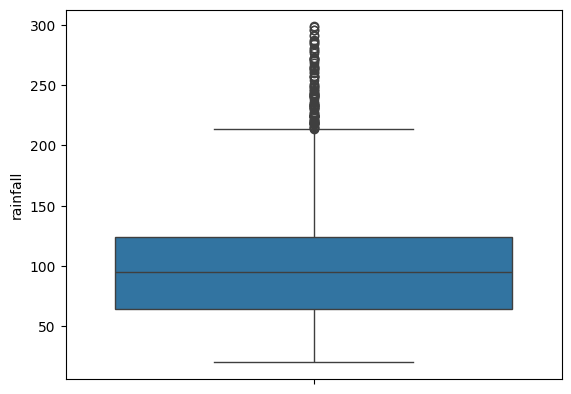

In [8]:
sns.boxplot(cr['rainfall'])
plt.show()

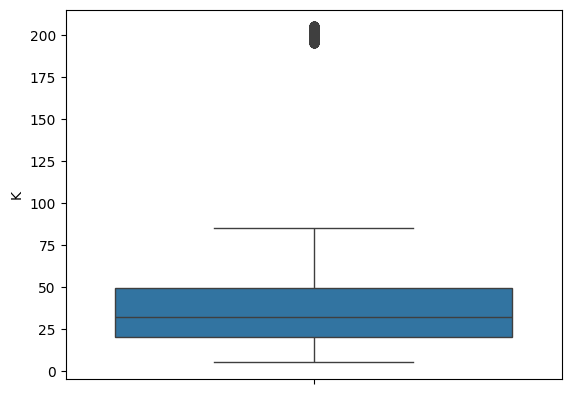

In [9]:
sns.boxplot(cr['K'])
plt.show()

In [10]:
cr.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [11]:
cr.duplicated().sum()

np.int64(0)

In [12]:
le=LabelEncoder()
cr['target']=le.fit_transform(cr['label'])

In [13]:
cr.head()

,N,P,K,temperature,humidity,ph,rainfall,label,target
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,20


In [14]:
x=cr.drop(['label','target'],axis=1)
y=cr['target']

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [16]:
x_train.head()

,N,P,K,temperature,humidity,ph,rainfall
1607,0,18,14,29.771494,92.007200,7.207991,114.416179
1212,9,122,201,29.587484,80.919344,5.570291,68.064173
362,11,71,24,21.140114,22.718235,5.606620,141.605672
566,38,38,18,26.310518,61.187491,6.294130,35.734038
1671,18,12,8,12.590940,91.816688,6.206053,119.391672


In [17]:
dt=DecisionTreeClassifier(random_state=42)


In [18]:
param_grid_dt={
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [19]:
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(x_train, y_train)

In [20]:
grid_dt.cv_results_

In [21]:
print("Best Parameters:", grid_dt.best_params_)

In [22]:
best_dt = grid_dt.best_estimator_

print("Train Accuracy:", best_dt.score(x_train, y_train))
print("Test Accuracy:", best_dt.score(x_test, y_test))

Train Accuracy: 0.9988636363636364
Test Accuracy: 0.9795454545454545


In [23]:
param_grid_rf={
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [24]:
rf=RandomForestClassifier(random_state=42)

In [25]:
grid_rf=GridSearchCV(
     estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_rf.fit(x_train,y_train)


In [26]:
print("Best Parameters:", grid_rf.best_params_)

In [27]:
best_rf=grid_rf.best_estimator_

In [28]:
 print("Train Accuracy:", best_rf.score(x_train, y_train))
print("Test Accuracy:", best_rf.score(x_test, y_test))

Train Accuracy: 0.9965909090909091
Test Accuracy: 0.9954545454545455


In [29]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [30]:
knn=KNeighborsClassifier()

In [31]:
param_grid_knn={
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [32]:
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_knn.fit(x_train_scaled,y_train)

In [33]:
print("Best Parameters:", grid_knn.best_params_)

In [34]:
best_knn=grid_knn.best_estimator_

In [35]:
print("Train Accuracy:", best_knn.score(x_train_scaled, y_train))
print("Test Accuracy:", best_knn.score(x_test_scaled, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9818181818181818

In [36]:
xgb=XGBClassifier(random_state=42)

In [37]:
param_grid_knn = {
    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate':  [0.001, 0.01, 0.1],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0]
}

In [38]:
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


In [39]:
grid_xgb.fit(x_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.001, 0.01, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=2)

In [40]:
print("Best Parameters:", grid_xgb.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [41]:
best_xgb=grid_xgb.best_estimator_

In [42]:
print("Train Accuracy:", best_xgb.score(x_train, y_train))
print("Test Accuracy:", best_xgb.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9954545454545455


Train Accuracy: 1.0 Test Accuracy: 0.9954545454545455

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "KNN": (best_knn, x_train_scaled, x_test_scaled),
    "Decision Tree": (best_dt, x_train, x_test),
    "Random Forest": (best_rf, x_train, x_test),
    "XGBoost": (best_xgb, x_train, x_test)
}

results = []

for name, (model, Xtr, Xte) in models.items():

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, average='weighted'),
        "Recall": recall_score(y_test, test_pred, average='weighted'),
        "F1 Score": f1_score(y_test, test_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

print(comparison_df)

In [44]:
import numpy as np

N = float(input("Enter Nitrogen: "))
P = float(input("Enter Phosphorus: "))
K = float(input("Enter Potassium: "))
temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))

sample = np.array([
    [N, P, K, temperature, humidity, ph, rainfall]
])

prediction = best_rf.predict(sample)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])